In [2]:
import numpy as np
import pandas as pd

print("Notebook started")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Notebook started
NumPy version: 2.4.1
Pandas version: 2.3.3


In [10]:
import os

REPO_ROOT = "/workspaces/neuro-ml-benchmark"
RESULTS_DIR = os.path.join(REPO_ROOT, "results", "runs", "run_0001_smoketest")
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Saving artifacts to:", RESULTS_DIR)


Saving artifacts to: /workspaces/neuro-ml-benchmark/results/runs/run_0001_smoketest


In [1]:
import sys
print(sys.executable)

/workspaces/neuro-ml-benchmark/.venv/bin/python


In [5]:
import mne
import numpy as np

print("MNE version:", mne.__version__)

# Built-in sample dataset path
data_path = mne.datasets.sample.data_path()
fif_path = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"

raw = mne.io.read_raw_fif(fif_path, preload=False, verbose=False)

print("Channels:", len(raw.ch_names))
print("Sampling rate (Hz):", raw.info["sfreq"])

data, times = raw[:, :1000]  # first 1000 samples
print("Data shape (channels x time):", data.shape)
print("Time range:", float(times[0]), "to", float(times[-1]))
print("Data dtype:", data.dtype)
print("Data min/max:", float(np.min(data)), float(np.max(data)))


MNE version: 1.11.0
Channels: 376
Sampling rate (Hz): 600.614990234375
Data shape (channels x time): (376, 1000)
Time range: 0.0 to 1.663295149543579
Data dtype: float64
Data min/max: -4.181671209302351e-05 0.0003314190692549346


Saved: /workspaces/neuro-ml-benchmark/results/runs/run_0001_smoketest/qc_signal_examples.png


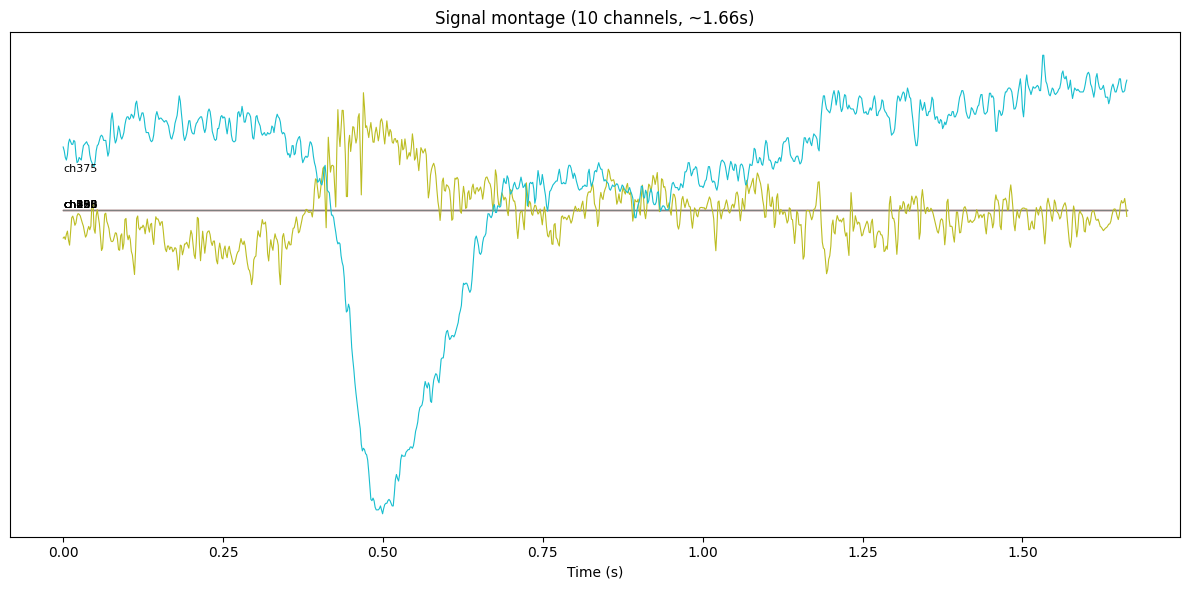

In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np

out_dir = "results/runs/run_0001_smoketest"
os.makedirs(out_dir, exist_ok=True)

n_plot = 10
idx = np.linspace(0, data.shape[0]-1, n_plot, dtype=int)

plt.figure(figsize=(12, 6))

offset = 0.0
for i, ch in enumerate(idx):
    x = data[ch]
    x = x - x.mean()
    plt.plot(times, x + offset, linewidth=0.8)
    plt.text(times[0], offset, f"ch{ch}", fontsize=8, va="bottom")
    offset += 1.2 * np.std(x)

plt.title("Signal montage (10 channels, ~1.66s)")
plt.xlabel("Time (s)")
plt.yticks([])
plt.tight_layout()

out_path = os.path.join(RESULTS_DIR, "qc_signal_examples.png")
plt.savefig(out_path, dpi=200)
print("Saved:", out_path)

